# Coverage dropout

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [54]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

# Million reads in each Qiagen full sample
full_Mreads = {
    "Q_B2_cell_01": 238,
    "Q_C2_cell_02": 185,
    "Q_D2_cell_03": 165,
    "Q_E2_cell_04": 169,
    "Q_F2_cell_05": 138,
    "Q_G2_cell_06": 185,
    "Q_A3_cell_07": 234,
    "Q_B3_cell_08": 212,
    "Q_C3_cell_09": 175,
    "Q_D3_cell_10": 110,
    "Q_H3_10_cells": 98
}

In [55]:

data = []
paths = {
    "2": "../analysis/downsample_qc/downstream_qc/multiqc_data/multiqc_general_stats.txt",
    "40": "../analysis/downsample_40M/downstream/multiqc_data/multiqc_general_stats.txt",
    "100+": "../analysis/qiagen_repli_g_full/downstream/multiqc_data/multiqc_general_stats.txt"
}
basedir = Path("../analysis")
assert basedir.exists()
for name, file in paths.items():
    #sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t")
    d["NGI ID"] = d["Sample"]
    d = d.merge(samples, on="NGI ID")

    d["Set"] = name
    if name == "100+":
        d["Mreads"] = d["User ID"].map(full_Mreads)
    else:
        d["Mreads"] = int(name)
    data.append(d)

data = pd.concat(data).reset_index(drop=True)

data["zero coverage"] = 100 - data["mosdepth_mqc-generalstats-mosdepth-1_x_pc"]
data.head()

,Sample_x,mosdepth_mqc-generalstats-mosdepth-1_x_pc,mosdepth_mqc-generalstats-mosdepth-5_x_pc,mosdepth_mqc-generalstats-mosdepth-10_x_pc,mosdepth_mqc-generalstats-mosdepth-30_x_pc,mosdepth_mqc-generalstats-mosdepth-50_x_pc,mosdepth_mqc-generalstats-mosdepth-median_coverage,mosdepth_mqc-generalstats-mosdepth-mean_coverage,mosdepth_mqc-generalstats-mosdepth-min_coverage,mosdepth_mqc-generalstats-mosdepth-max_coverage,...,NGI ID,User ID,IsSingleCell,Kit,Sample_y,Genome,Type,Set,Mreads,zero coverage
0,P33410_1001,11.549,0.124,0.0,0.0,0.0,0.0,0.17423,0.0,237.0,...,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,2,2,88.451
1,P33410_1002,11.403,0.152,0.0,0.0,0.0,0.0,0.17463,0.0,221.0,...,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell,2,2,88.597
2,P33410_1003,11.021,0.193,0.0,0.0,0.0,0.0,0.17396,0.0,205.0,...,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell,2,2,88.979
3,P33410_1004,11.192,0.151,0.0,0.0,0.0,0.0,0.17308,0.0,411.0,...,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Single cell,2,2,88.808
4,P33410_1005,11.308,0.147,0.0,0.0,0.0,0.0,0.17402,0.0,257.0,...,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Single cell,2,2,88.692


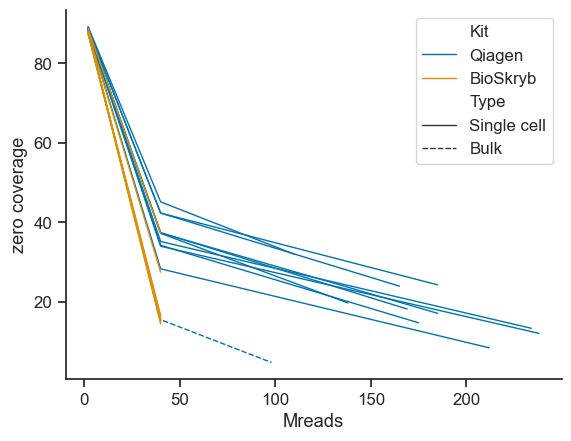

In [58]:
ax = sns.lineplot(
    data=data,
    x="Mreads",
    y="zero coverage",
    hue="Kit",
    style="Type",
    units="NGI ID",
    estimator=None,
    lw=1,
)

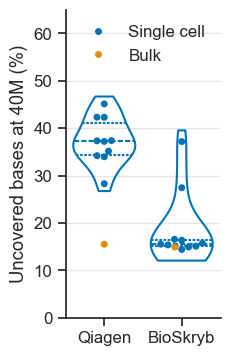

In [199]:
d = data.query("Set == '40'")

fig, ax = plt.subplots(figsize=(2, 4))

ax = sns.violinplot(
    data=d.query('Type == "Single cell"'), 
    x="Kit", 
    y="zero coverage", 
    inner="quart", 
    fill=None, 
    cut=0.5,
    density_norm="width", 
    ax=ax,
    legend=False
)
ax = sns.swarmplot(
    data=d,
    x="Kit",
    y="zero coverage",
    hue="Type",
    ax=ax
)
ax.set_ylabel("Uncovered bases at 40M (%)")
ax.set_ylim(0,65)
plt.legend(frameon=False, framealpha=0)
ax.set_xlabel("")
sns.move_legend(ax, loc="upper right")
ax.grid(True, axis='y', alpha=0.5)
plt.savefig(figdir / "uncovered_bases.svg", bbox_inches="tight")

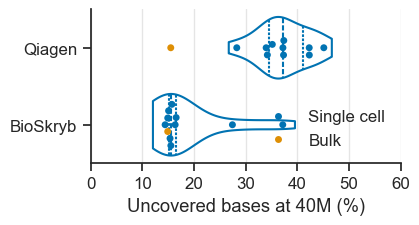

In [200]:
d = data.query("Set == '40'")

fig, ax = plt.subplots(figsize=(4, 2))

ax = sns.violinplot(
    data=d.query('Type == "Single cell"'), 
    y="Kit", 
    x="zero coverage", 
    inner="quart", 
    fill=None, 
    cut=0.5,
    density_norm="width", 
    ax=ax,
    legend=False
)
ax = sns.swarmplot(
    data=d,
    y="Kit",
    x="zero coverage",
    hue="Type",
    ax=ax
)
ax.set_xlabel("Uncovered bases at 40M (%)")
ax.set_xlim(0,60)
plt.legend(frameon=False, framealpha=0)
ax.set_ylabel("")
sns.move_legend(ax, loc="lower right")
ax.grid(True, axis='x', alpha=0.5)
plt.savefig(figdir / "uncovered_bases_h.svg", bbox_inches="tight")

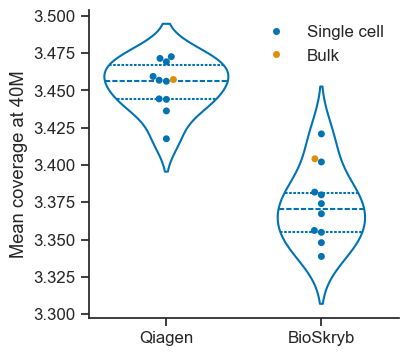

In [153]:
d = data.query("Set == '40'")

fig, ax = plt.subplots(figsize=(4, 4))

ax = sns.violinplot(
    data=d.query('Type == "Single cell"'), 
    x="Kit", 
    y="mosdepth_mqc-generalstats-mosdepth-mean_coverage", 
    inner="quart", 
    fill=None, 
    #color="k", 
    ax=ax,
    legend=False
)
ax = sns.swarmplot(
    data=d,
    x="Kit",
    y="mosdepth_mqc-generalstats-mosdepth-mean_coverage",
    hue="Type",
    ax=ax
)
ax.set_ylabel("Mean coverage at 40M")
#ax.set_ylim(0,60)
plt.legend(frameon=False, framealpha=0)
ax.set_xlabel("")
sns.move_legend(ax, loc="upper right")

#plt.savefig(figdir / "uncovered_bases.svg", bbox_inches="tight")

## Mosdepth coverage

In [ ]:
depth = []

basepath = Path("../analysis/downsample_40M/downstream/mosdepth")
for sample in human_samples["NGI ID"]:
    tsv = basepath / f"{sample}.mosdepth.global.dist.txt"
    d = pd.read_csv(tsv, sep="\t", names=["region", "depth", "cumulative"])
    #d = d.query("region == 'total'")
    d["relative_depth"] = d.groupby("region")["cumulative"].transform(
        lambda x: x.rolling(2).apply(lambda x: x.iloc[1]-x.iloc[0]).fillna(0))
    d["cumulative_percentage"] = d["cumulative"] * 100
    d["NGI ID"] = sample
    d = d.merge(samples, on="NGI ID")
    depth.append(d)

depth = pd.concat(depth).reset_index(drop=True)
depth.head()

,region,depth,cumulative,relative_depth,cumulative_percentage,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type
0,chr1,74,0.00008,0.00000,0.008,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
1,chr1,73,0.00009,0.00001,0.009,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
2,chr1,72,0.00010,0.00001,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
3,chr1,71,0.00010,0.00000,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
4,chr1,70,0.00011,0.00001,0.011,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell


In [207]:
depth

,region,depth,cumulative,relative_depth,cumulative_percentage,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type
0,chr1,74,0.00008,0.00000,0.008,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
1,chr1,73,0.00009,0.00001,0.009,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
2,chr1,72,0.00010,0.00001,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
3,chr1,71,0.00010,0.00000,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
4,chr1,70,0.00011,0.00001,0.011,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell
...,...,...,...,...,...,...,...,...,...,...,...,...
225660,total,4,0.41133,0.10820,41.133,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk
225661,total,3,0.53238,0.12105,53.238,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk
225662,total,2,0.67360,0.14122,67.360,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk
225663,total,1,0.78556,0.11196,78.556,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk


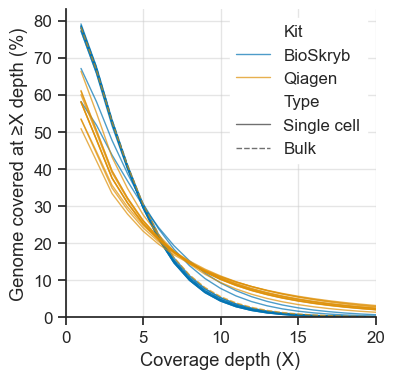

In [213]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.lineplot(
    data=depth.query("depth > 0 & region == 'total'"),
    x="depth",
    y="cumulative_percentage",
    hue="Kit",
    hue_order=reversed(["Qiagen", "BioSkryb"]),
    style="Type",
    style_order=["Single cell", "Bulk"],
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.set_ylabel("Genome covered at ≥X depth (%)")
ax.set_xlabel("Coverage depth (X)")
ax.grid(True, axis='both', alpha=0.5)
plt.legend(edgecolor="w", framealpha=1, loc="upper right")

plt.savefig(figdir / "coverage_depth.svg", bbox_inches="tight")

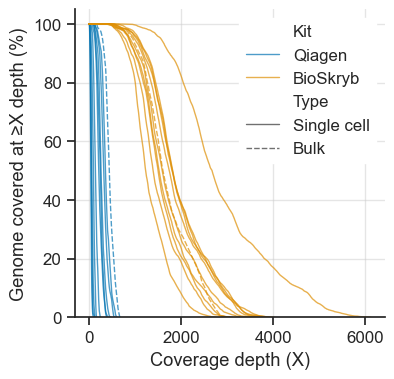

In [198]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.lineplot(
    data=depth.query("depth > 0 and region == 'chrM'"),
    x="depth",
    y="cumulative_percentage",
    hue="Kit",
    hue_order=["Qiagen", "BioSkryb"],
    style="Type",
    style_order=["Single cell", "Bulk"],
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
)
#ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.set_ylabel("Genome covered at ≥X depth (%)")
ax.set_xlabel("Coverage depth (X)")
ax.grid(True, axis='both', alpha=0.5)
plt.legend(edgecolor="w", framealpha=1, loc="upper right")
#plt.savefig(figdir / "coverage_depth.svg", bbox_inches="tight")

## Preseq GC extrap

In [144]:
datagc = []
# Command: less /sw/data/igenomes/Homo_sapiens/NCBI/GRCh38/Sequence/WholeGenomeFasta/genome.fa.fai | awk '{sum += $2} END {print sum}'
genome_territory = 3099922541

basepath = Path("../analysis/downsample_40M/downstream/preseq")
for sample in human_samples["NGI ID"]:
    tsv = basepath / f"{sample}.gc_extrap.txt"
    d = pd.read_csv(tsv, sep="\t")
    d["NGI ID"] = sample
    d = d.merge(samples, on="NGI ID")
    datagc.append(d)

datagc = pd.concat(datagc).reset_index(drop=True)
datagc["Genome coverage"] = datagc["EXPECTED_COVERED_BASES"] / genome_territory * 100
datagc["Gb"] = datagc["TOTAL_BASES"] / 1e9
datagc = datagc[datagc["LOWER_95%CI"] > 0]
datagc

,TOTAL_BASES,EXPECTED_COVERED_BASES,LOWER_95%CI,UPPER_95%CI,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,Type,Genome coverage,Gb
1,1.000000e+08,9.510731e+07,9.509543e+07,9.511725e+07,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,3.068054,0.1
2,2.000000e+08,1.818907e+08,1.818745e+08,1.819053e+08,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,5.867589,0.2
3,3.000000e+08,2.616127e+08,2.615889e+08,2.616356e+08,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,8.439329,0.3
4,4.000000e+08,3.352197e+08,3.351943e+08,3.352462e+08,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,10.813808,0.4
5,5.000000e+08,4.034693e+08,4.034386e+08,4.035040e+08,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,13.015464,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
219995,9.995000e+11,2.962011e+09,2.597250e+09,3.488541e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk,95.551126,999.5
219996,9.996000e+11,2.962011e+09,2.597254e+09,3.488540e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk,95.551131,999.6
219997,9.997000e+11,2.962011e+09,2.597257e+09,3.488539e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk,95.551135,999.7
219998,9.998000e+11,2.962011e+09,2.597261e+09,3.488538e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,Bulk,95.551140,999.8


In [ ]:
bases = []

paths = {
    "2": Path("../analysis/downsample_qc/downstream_qc"),
    "40": Path("../analysis/downsample_40M/downstream"),
    "100+": Path("../analysis/qiagen_repli_g_full/downstream")
}

for sample in human_samples["NGI ID"]:
    for s, path in paths.items():
        log = path / "preseq" /  f"{sample}.gc_extrap.txt.log"
        if not log.exists():
            print(log)
            continue
    
        n_bases = 0
        n_covered = 0 
        with open(log) as f:
            for line in f:
                if line.startswith("TOTAL BASES"):
                    n_bases = float(line.strip().split("=")[1])
                
                if line.startswith("TOTAL COVERED BASES"):
                    n_covered = float(line.strip().split("=")[1])

        bases.append({"NGI ID": sample, "TOTAL_BASES": n_bases, "EXPECTED_COVERED_BASES": n_covered, "Set": s})

bases = pd.DataFrame(bases)
bases = bases.merge(samples, on="NGI ID")
bases["Genome coverage"] = bases["EXPECTED_COVERED_BASES"] / genome_territory * 100
bases["Gb"] = bases["TOTAL_BASES"] / 1e9
bases


../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1013.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1014.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1015.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1016.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1017.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1018.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1019.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1020.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1021.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1022.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1024.gc_extrap.txt.log


,NGI ID,TOTAL_BASES,EXPECTED_COVERED_BASES,Set,User ID,IsSingleCell,Kit,Sample,Genome,Type,Genome coverage,Gb
0,P33410_1001,5.408960e+08,3.315120e+08,2,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,10.694203,0.540896
1,P33410_1001,1.082780e+10,1.928780e+09,40,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,62.220264,10.827800
2,P33410_1001,6.435600e+10,2.588600e+09,100+,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Single cell,83.505312,64.356000
3,P33410_1002,5.411660e+08,3.267040e+08,2,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell,10.539102,0.541166
4,P33410_1002,1.082770e+10,1.831430e+09,40,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell,59.079863,10.827700
5,P33410_1002,5.010050e+10,2.441830e+09,100+,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Single cell,78.770678,50.100500
6,P33410_1003,5.391040e+08,3.161330e+08,2,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell,10.198094,0.539104
7,P33410_1003,1.078890e+10,1.690170e+09,40,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell,54.522975,10.788900
8,P33410_1003,4.455340e+10,2.244240e+09,100+,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Single cell,72.396648,44.553400
9,P33410_1004,5.374530e+08,3.213530e+08,2,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Single cell,10.366485,0.537453


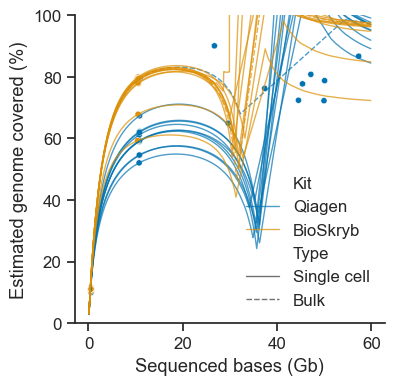

In [145]:
# Plot the genome coverage
datagc = datagc.sort_values("Kit", ascending=False)
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.lineplot(
    data=datagc.query("TOTAL_BASES < 6e10"),
    x="Gb",
    y="Genome coverage",
    hue="Kit",
    hue_order=["Qiagen", "BioSkryb"],
    style="Type",
    style_order=["Single cell", "Bulk"],
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
)

ax = sns.scatterplot(
    data=bases.query("TOTAL_BASES < 6e10"),
    x="Gb",
    y="Genome coverage",
    hue="Kit",
    hue_order=["Qiagen", "BioSkryb"],
    s=20,
    ax=ax,
    legend=False
)
ax.set_ylabel("Estimated genome covered (%)")
ax.set_xlabel("Sequenced bases (Gb)")
plt.legend(frameon=False, framealpha=0)
ax.set_ylim(0, 100)
plt.savefig(figdir / "gc_extrap_genome_coverage_40M.svg", bbox_inches="tight")
